In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

# Make plots a bit cleaner
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Create folders for outputs
BASE_DIR = "/content/Assignment_5"
FIG_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Figure directory:", FIG_DIR)

Base directory: /content/Assignment_5
Figure directory: /content/Assignment_5/figures


In [3]:
# Upload data.csv from your computer
uploaded = files.upload()

Saving data.csv to data.csv


In [4]:
# Reload the CSV correctly: the file has no header row
csv_path = "/content/data.csv"

df = pd.read_csv(csv_path, header=None)
df.columns = ["feature_1", "feature_2", "label"]

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully.
Shape: (100, 3)

First 5 rows:


,feature_1,feature_2,label
0,0.78051,-0.063669,1
1,0.28774,0.291390,1
2,0.40714,0.178780,1
3,0.29230,0.421700,1
4,0.50922,0.352560,1


In [5]:
print("Column names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Column names: ['feature_1', 'feature_2', 'label']

Data types:
feature_1    float64
feature_2    float64
label          int64
dtype: object

Missing values:
feature_1    0
feature_2    0
label        0
dtype: int64


In [6]:
X = df[["feature_1", "feature_2"]].values
y = df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))

X shape: (100, 2)
y shape: (100,)
Unique labels: [0 1]


In [7]:
def plot_dataset(X, y, save_path=None, show=True):
    plt.figure(figsize=(8, 6))

    class0 = (y == 0)
    class1 = (y == 1)

    plt.scatter(X[class0, 0], X[class0, 1], label="Class 0")
    plt.scatter(X[class1, 0], X[class1, 1], label="Class 1")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Dataset Scatter Plot")
    plt.legend()
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {save_path}")

    if show:
        plt.show()
    else:
        plt.close()

Saved figure: /content/Assignment_5/figures/dataset_scatter.png


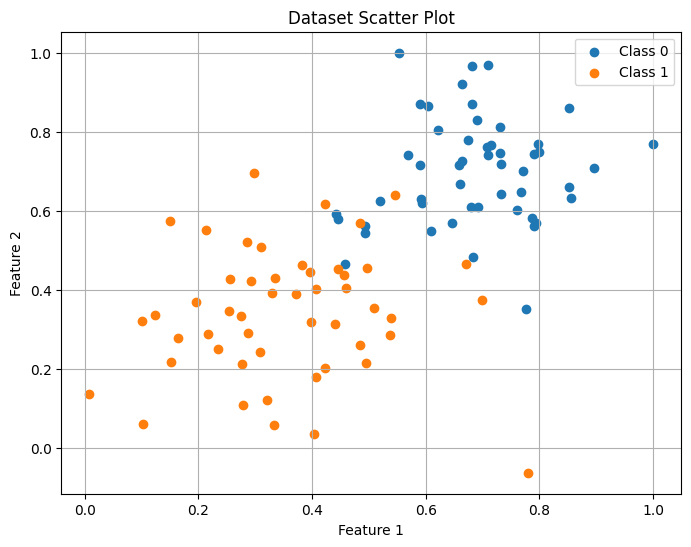

In [8]:
raw_data_fig = os.path.join(FIG_DIR, "dataset_scatter.png")
plot_dataset(X, y, save_path=raw_data_fig)

In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_probability(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

def predict_class(X, w, b, threshold=0.5):
    probs = predict_probability(X, w, b)
    return (probs >= threshold).astype(int)

def compute_log_loss(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

In [10]:
def plot_decision_boundaries(X, y, history, title, save_path=None, max_intermediate_lines=None):
    """
    history: list of tuples (w, b)
             history[0] = initial line
             history[1:-1] = intermediate lines
             history[-1] = final line
    """
    plt.figure(figsize=(8, 6))

    class0 = (y == 0)
    class1 = (y == 1)

    plt.scatter(X[class0, 0], X[class0, 1], label="Class 0")
    plt.scatter(X[class1, 0], X[class1, 1], label="Class 1")

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x_vals = np.linspace(x_min, x_max, 200)

    def draw_line(w, b, color, linestyle, linewidth, label=None):
        # For boundary: w1*x1 + w2*x2 + b = 0
        if abs(w[1]) < 1e-12:
            return
        y_vals = -(w[0] * x_vals + b) / w[1]
        plt.plot(x_vals, y_vals, color=color, linestyle=linestyle, linewidth=linewidth, label=label)

    # Initial line
    if len(history) >= 1:
        w0, b0 = history[0]
        draw_line(w0, b0, color="red", linestyle="-", linewidth=2, label="Initial line")

    # Intermediate lines
    middle = history[1:-1]
    if max_intermediate_lines is not None and len(middle) > max_intermediate_lines:
        idx = np.linspace(0, len(middle) - 1, max_intermediate_lines, dtype=int)
        middle = [middle[i] for i in idx]

    for i, (w, b) in enumerate(middle):
        draw_line(w, b, color="green", linestyle="--", linewidth=1, label="Intermediate lines" if i == 0 else None)

    # Final line
    if len(history) >= 2:
        wf, bf = history[-1]
        draw_line(wf, bf, color="black", linestyle="-", linewidth=2.5, label="Final line")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {save_path}")

    plt.show()

Saved figure: /content/Assignment_5/figures/boundary_plot_test.png


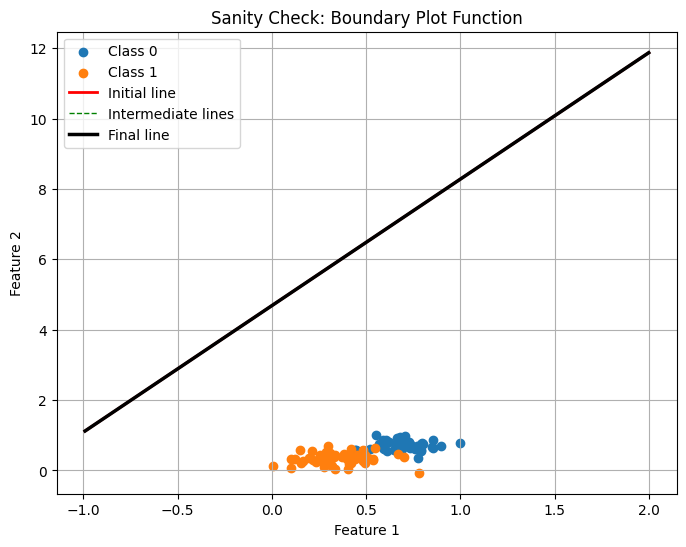

In [11]:
# Random test line just to verify boundary plotting works
np.random.seed(42)
test_w = np.random.randn(2)
test_b = np.random.randn()

history_test = [
    (test_w, test_b),
    (test_w * 0.8, test_b * 0.8),
    (test_w * 0.6, test_b * 0.6)
]

test_fig = os.path.join(FIG_DIR, "boundary_plot_test.png")
plot_decision_boundaries(
    X, y,
    history=history_test,
    title="Sanity Check: Boundary Plot Function",
    save_path=test_fig
)

In [12]:
def train_part1_heuristic(X, y, learning_rate=0.1, epochs=50, seed=42):
    np.random.seed(seed)

    n_features = X.shape[1]
    w = np.random.randn(n_features)
    b = np.random.randn()

    history = [(w.copy(), b)]   # initial line
    epoch_losses = []

    for epoch in range(epochs):
        for i in range(len(X)):
            x_i = X[i]
            y_i = y[i]

            y_hat = sigmoid(np.dot(w, x_i) + b)   # continuous output
            error = y_i - y_hat

            b = b + learning_rate * error
            w = w + learning_rate * error * x_i

        # Compute loss after each epoch for optional analysis
        y_prob = predict_probability(X, w, b)
        loss = compute_log_loss(y, y_prob)
        epoch_losses.append(loss)

        history.append((w.copy(), b))

    return w, b, history, epoch_losses

In [13]:
part1_lr = 0.1
part1_epochs = 50

w1, b1, history1, loss1 = train_part1_heuristic(
    X, y,
    learning_rate=part1_lr,
    epochs=part1_epochs,
    seed=42
)

print("Part 1 baseline training complete.")
print("Final weights:", w1)
print("Final bias:", b1)
print("Final log loss:", loss1[-1])

Part 1 baseline training complete.
Final weights: [-7.06816321 -7.89013675]
Final bias: 7.285029485060135
Final log loss: 0.193322009351366


Saved figure: /content/Assignment_5/figures/part1_lr_0.1_ep_50.png


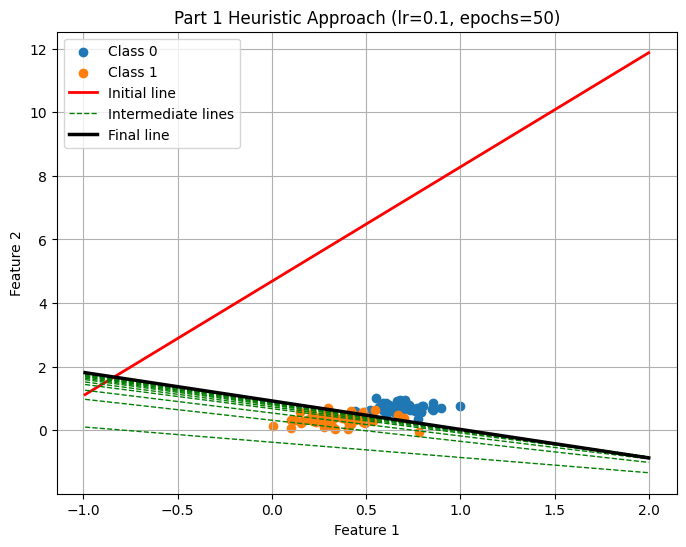

In [14]:
part1_baseline_fig = os.path.join(FIG_DIR, f"part1_lr_{part1_lr}_ep_{part1_epochs}.png")

plot_decision_boundaries(
    X, y,
    history=history1,
    title=f"Part 1 Heuristic Approach (lr={part1_lr}, epochs={part1_epochs})",
    save_path=part1_baseline_fig,
    max_intermediate_lines=15
)

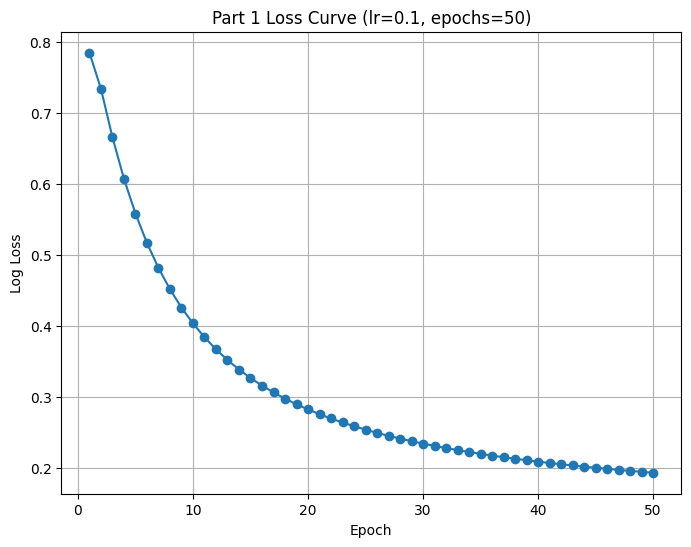

In [15]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(loss1) + 1), loss1, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title(f"Part 1 Loss Curve (lr={part1_lr}, epochs={part1_epochs})")
plt.grid(True)
plt.show()

Saved figure: /content/Assignment_5/figures/part1_lr_0.01_ep_50.png


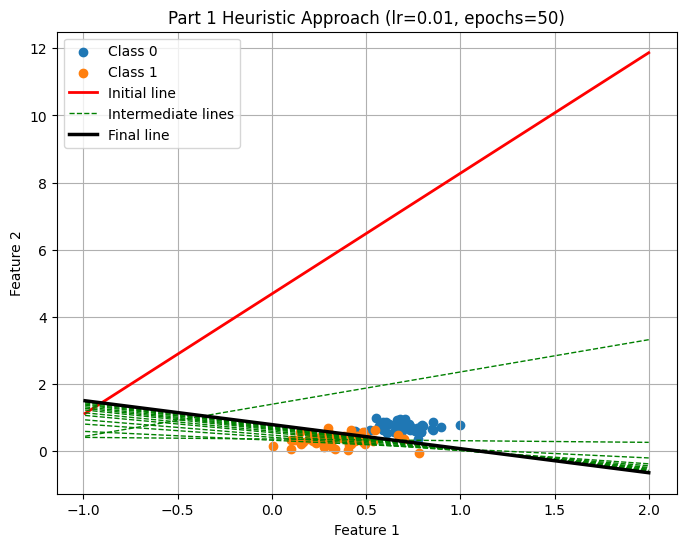

Saved figure: /content/Assignment_5/figures/part1_lr_0.1_ep_50.png


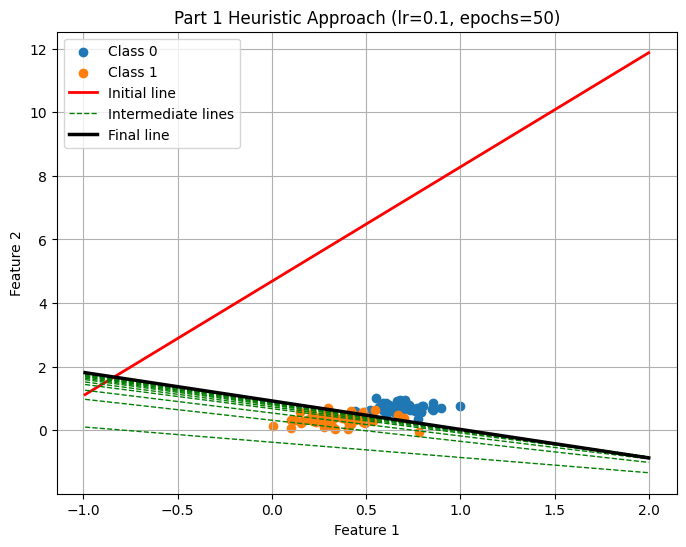

Saved figure: /content/Assignment_5/figures/part1_lr_1.0_ep_50.png


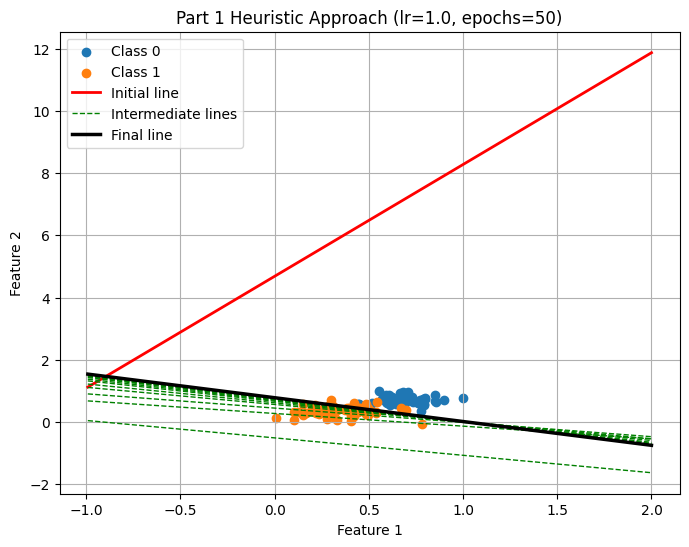

In [16]:
part1_learning_rates = [0.01, 0.1, 1.0]
part1_fixed_epochs = 50

part1_results_lr = {}

for lr in part1_learning_rates:
    w, b, history, losses = train_part1_heuristic(
        X, y,
        learning_rate=lr,
        epochs=part1_fixed_epochs,
        seed=42
    )

    part1_results_lr[lr] = {
        "w": w,
        "b": b,
        "history": history,
        "losses": losses
    }

    save_path = os.path.join(FIG_DIR, f"part1_lr_{lr}_ep_{part1_fixed_epochs}.png")

    plot_decision_boundaries(
        X, y,
        history=history,
        title=f"Part 1 Heuristic Approach (lr={lr}, epochs={part1_fixed_epochs})",
        save_path=save_path,
        max_intermediate_lines=15
    )

Saved figure: /content/Assignment_5/figures/part1_lr_0.1_ep_20.png


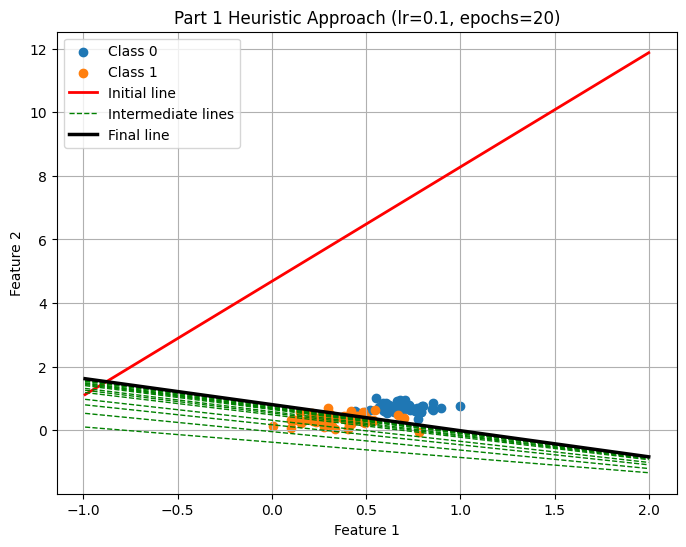

Saved figure: /content/Assignment_5/figures/part1_lr_0.1_ep_50.png


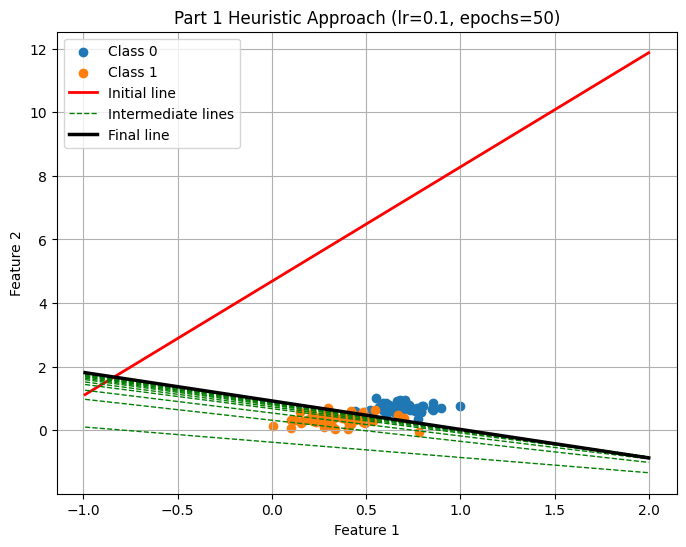

Saved figure: /content/Assignment_5/figures/part1_lr_0.1_ep_100.png


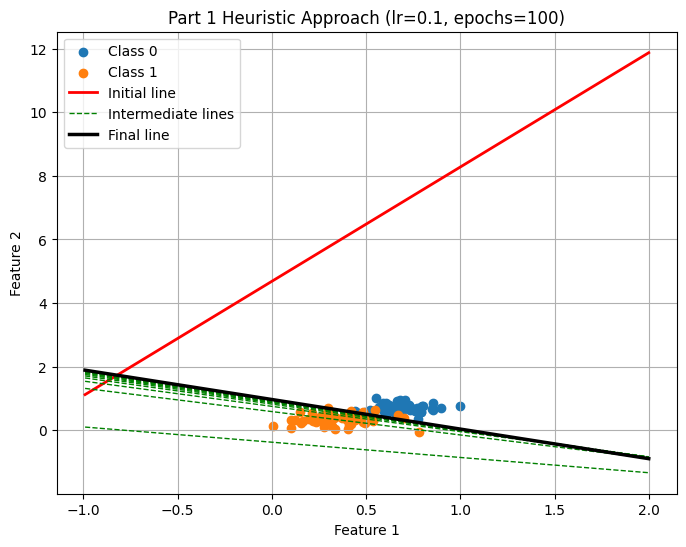

In [17]:
part1_fixed_lr = 0.1
part1_epoch_list = [20, 50, 100]

part1_results_ep = {}

for ep in part1_epoch_list:
    w, b, history, losses = train_part1_heuristic(
        X, y,
        learning_rate=part1_fixed_lr,
        epochs=ep,
        seed=42
    )

    part1_results_ep[ep] = {
        "w": w,
        "b": b,
        "history": history,
        "losses": losses
    }

    save_path = os.path.join(FIG_DIR, f"part1_lr_{part1_fixed_lr}_ep_{ep}.png")

    plot_decision_boundaries(
        X, y,
        history=history,
        title=f"Part 1 Heuristic Approach (lr={part1_fixed_lr}, epochs={ep})",
        save_path=save_path,
        max_intermediate_lines=15
    )

In [18]:
part1_summary = []

for lr, result in part1_results_lr.items():
    final_loss = result["losses"][-1]
    y_pred = predict_class(X, result["w"], result["b"])
    accuracy = np.mean(y_pred == y)

    part1_summary.append({
        "experiment": f"lr={lr}, epochs={part1_fixed_epochs}",
        "final_log_loss": final_loss,
        "accuracy": accuracy
    })

for ep, result in part1_results_ep.items():
    final_loss = result["losses"][-1]
    y_pred = predict_class(X, result["w"], result["b"])
    accuracy = np.mean(y_pred == y)

    part1_summary.append({
        "experiment": f"lr={part1_fixed_lr}, epochs={ep}",
        "final_log_loss": final_loss,
        "accuracy": accuracy
    })

part1_summary_df = pd.DataFrame(part1_summary)
display(part1_summary_df)

,experiment,final_log_loss,accuracy
0,"lr=0.01, epochs=50",0.414441,0.93
1,"lr=0.1, epochs=50",0.193322,0.93
2,"lr=1.0, epochs=50",0.277245,0.91
3,"lr=0.1, epochs=20",0.282453,0.91
4,"lr=0.1, epochs=50",0.193322,0.93
5,"lr=0.1, epochs=100",0.161638,0.93


In [19]:
def train_part2_gradient_descent(X, y, learning_rate=0.1, epochs=50, seed=42):
    np.random.seed(seed)

    n_features = X.shape[1]
    w = np.random.randn(n_features)
    b = np.random.randn()

    history = [(w.copy(), b)]   # initial line
    epoch_losses = []
    epoch_accuracies = []
    misclassified_counts = []

    for epoch in range(epochs):
        misclassified = 0

        for i in range(len(X)):
            x_i = X[i]
            y_i = y[i]

            # Predicted class using thresholded sigmoid
            y_pred = int(sigmoid(np.dot(w, x_i) + b) >= 0.5)

            if y_pred != y_i:
                misclassified += 1

                # Follow the assignment's right-box rule
                if y_pred == 0:
                    b = b + learning_rate
                    w = w + learning_rate * x_i
                elif y_pred == 1:
                    b = b - learning_rate
                    w = w - learning_rate * x_i

        y_prob = predict_probability(X, w, b)
        y_class = (y_prob >= 0.5).astype(int)

        loss = compute_log_loss(y, y_prob)
        acc = np.mean(y_class == y)

        epoch_losses.append(loss)
        epoch_accuracies.append(acc)
        misclassified_counts.append(misclassified)
        history.append((w.copy(), b))

    return w, b, history, epoch_losses, epoch_accuracies, misclassified_counts

In [20]:
part2_lr = 0.1
part2_epochs = 50

w2, b2, history2, loss2, acc2, mis2 = train_part2_gradient_descent(
    X, y,
    learning_rate=part2_lr,
    epochs=part2_epochs,
    seed=42
)

print("Part 2 baseline training complete.")
print("Final weights:", w2)
print("Final bias:", b2)
print("Final log loss:", loss2[-1])
print("Final accuracy:", acc2[-1])
print("Last epoch misclassified count:", mis2[-1])

Part 2 baseline training complete.
Final weights: [-0.43015585 -0.7940533 ]
Final bias: 0.5476885381006925
Final log loss: 0.5953275822442393
Final accuracy: 0.92
Last epoch misclassified count: 4


Saved figure: /content/Assignment_5/figures/part2_boundary_lr_0.1_ep_50.png


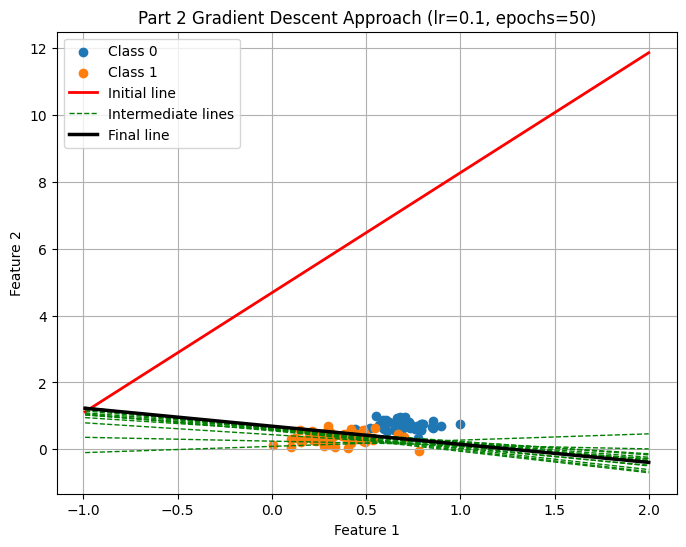

In [21]:
part2_baseline_boundary_fig = os.path.join(FIG_DIR, f"part2_boundary_lr_{part2_lr}_ep_{part2_epochs}.png")

plot_decision_boundaries(
    X, y,
    history=history2,
    title=f"Part 2 Gradient Descent Approach (lr={part2_lr}, epochs={part2_epochs})",
    save_path=part2_baseline_boundary_fig,
    max_intermediate_lines=15
)

Saved figure: /content/Assignment_5/figures/part2_loss_lr_0.1_ep_50.png


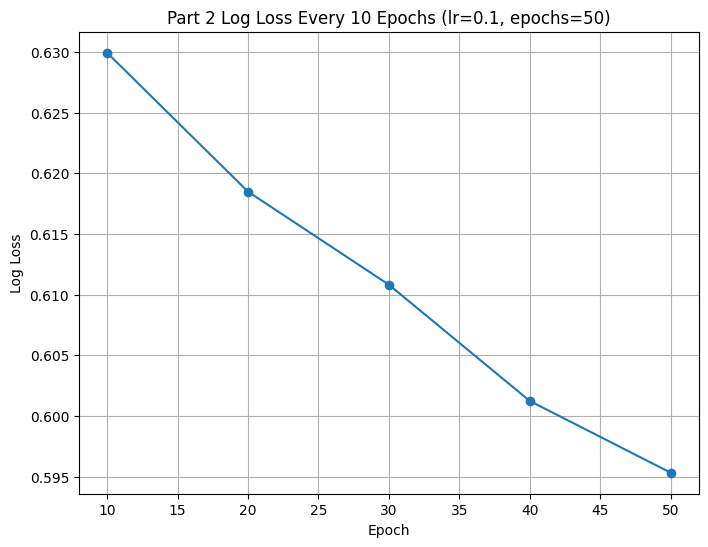

In [22]:
epochs_axis_10 = list(range(10, part2_epochs + 1, 10))
loss_every_10 = [loss2[i - 1] for i in epochs_axis_10]

plt.figure(figsize=(8, 6))
plt.plot(epochs_axis_10, loss_every_10, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title(f"Part 2 Log Loss Every 10 Epochs (lr={part2_lr}, epochs={part2_epochs})")
plt.grid(True)

part2_baseline_loss_fig = os.path.join(FIG_DIR, f"part2_loss_lr_{part2_lr}_ep_{part2_epochs}.png")
plt.savefig(part2_baseline_loss_fig, dpi=300, bbox_inches="tight")
print(f"Saved figure: {part2_baseline_loss_fig}")
plt.show()

Saved figure: /content/Assignment_5/figures/part2_boundary_lr_0.01_ep_50.png


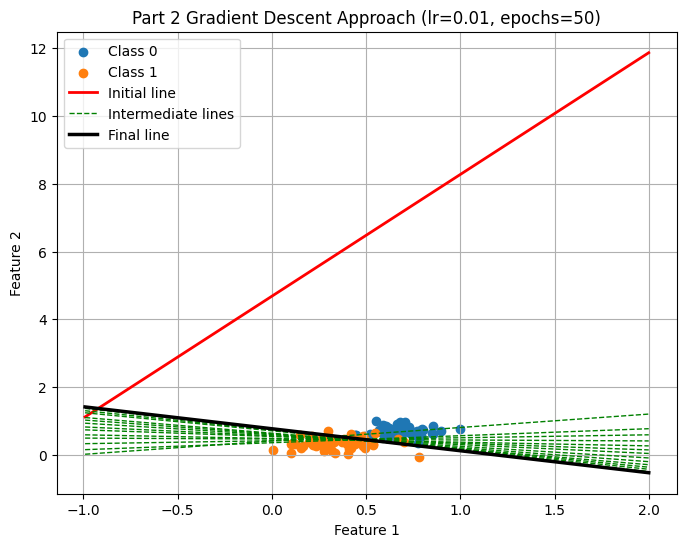

Saved figure: /content/Assignment_5/figures/part2_loss_lr_0.01_ep_50.png


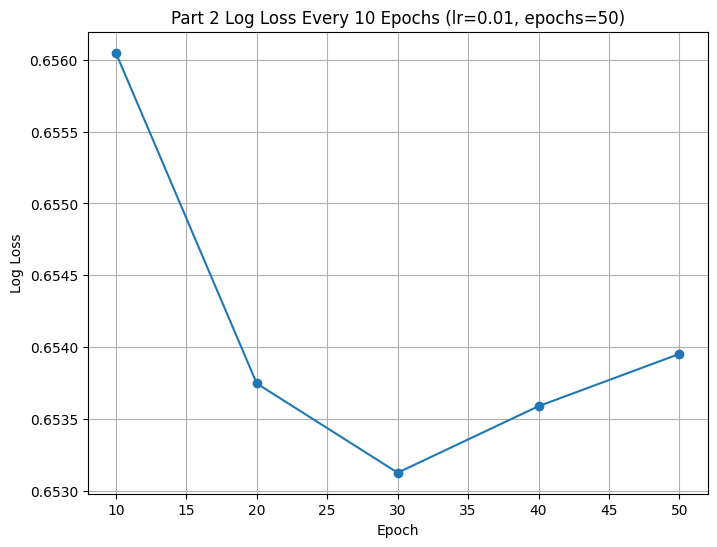

Saved figure: /content/Assignment_5/figures/part2_boundary_lr_0.1_ep_50.png


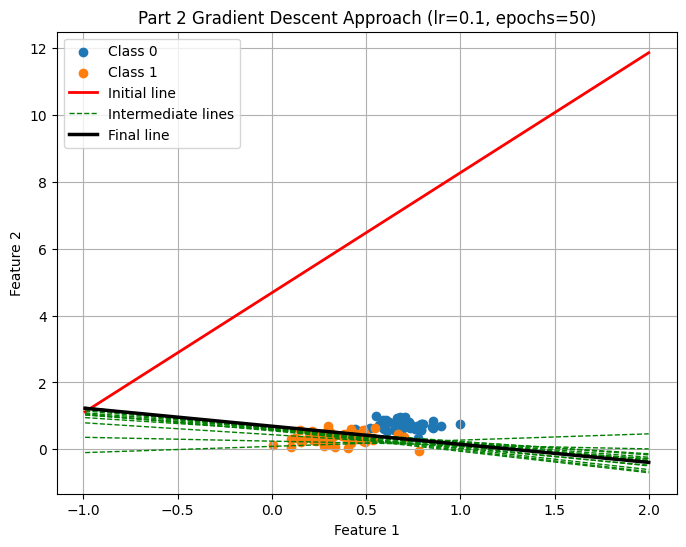

Saved figure: /content/Assignment_5/figures/part2_loss_lr_0.1_ep_50.png


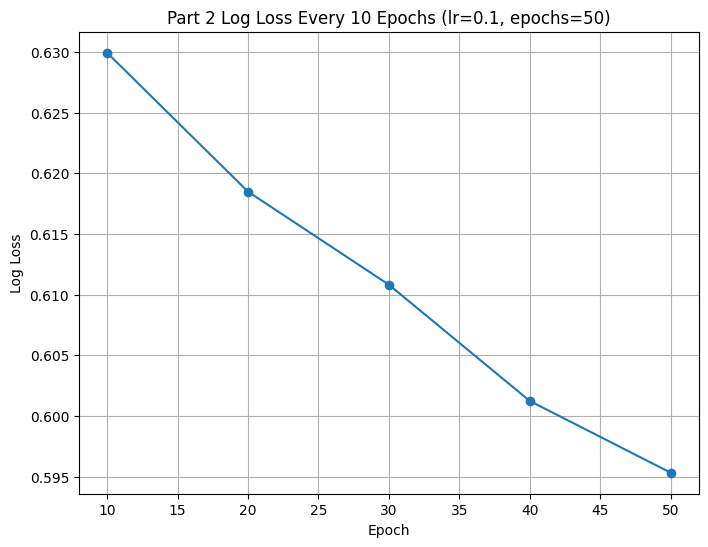

Saved figure: /content/Assignment_5/figures/part2_boundary_lr_1.0_ep_50.png


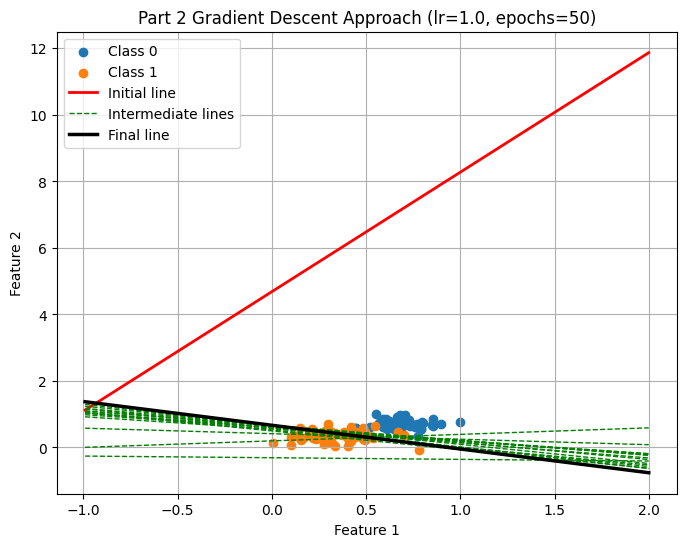

Saved figure: /content/Assignment_5/figures/part2_loss_lr_1.0_ep_50.png


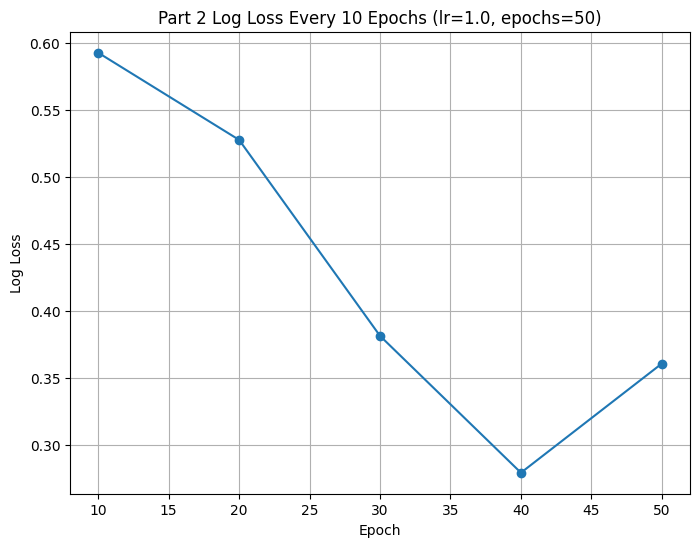

In [24]:
part2_learning_rates = [0.01, 0.1, 1.0]
part2_fixed_epochs = 50

part2_results_lr = {}

for lr in part2_learning_rates:
    w, b, history, losses, accuracies, misclassified = train_part2_gradient_descent(
        X, y,
        learning_rate=lr,
        epochs=part2_fixed_epochs,
        seed=42
    )

    part2_results_lr[lr] = {
        "w": w,
        "b": b,
        "history": history,
        "losses": losses,
        "accuracies": accuracies,
        "misclassified": misclassified
    }

    boundary_save_path = os.path.join(FIG_DIR, f"part2_boundary_lr_{lr}_ep_{part2_fixed_epochs}.png")
    plot_decision_boundaries(
        X, y,
        history=history,
        title=f"Part 2 Gradient Descent Approach (lr={lr}, epochs={part2_fixed_epochs})",
        save_path=boundary_save_path,
        max_intermediate_lines=15
    )

    epochs_axis_10 = list(range(10, part2_fixed_epochs + 1, 10))
    loss_every_10 = [losses[i - 1] for i in epochs_axis_10]

    plt.figure(figsize=(8, 6))
    plt.plot(epochs_axis_10, loss_every_10, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Log Loss")
    plt.title(f"Part 2 Log Loss Every 10 Epochs (lr={lr}, epochs={part2_fixed_epochs})")
    plt.grid(True)

    loss_save_path = os.path.join(FIG_DIR, f"part2_loss_lr_{lr}_ep_{part2_fixed_epochs}.png")
    plt.savefig(loss_save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {loss_save_path}")
    plt.show()

Saved figure: /content/Assignment_5/figures/part2_boundary_lr_0.1_ep_20.png


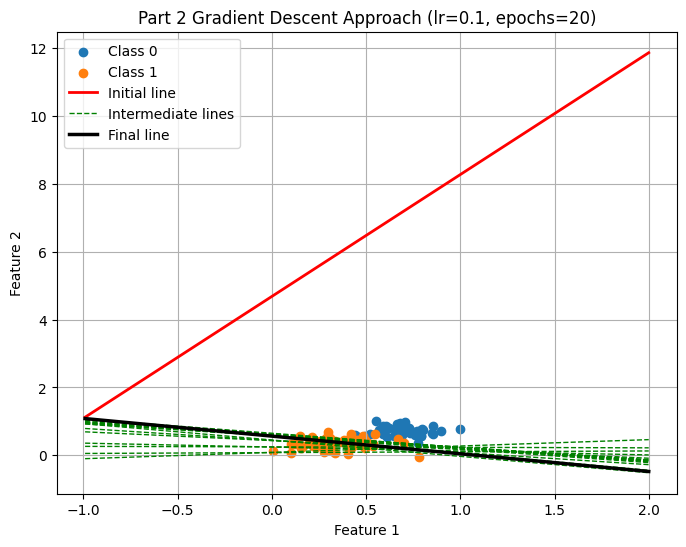

Saved figure: /content/Assignment_5/figures/part2_loss_lr_0.1_ep_20.png


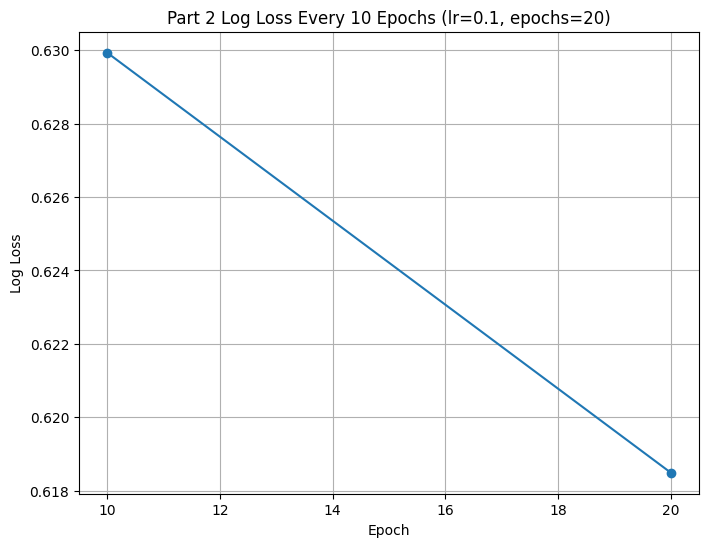

Saved figure: /content/Assignment_5/figures/part2_boundary_lr_0.1_ep_50.png


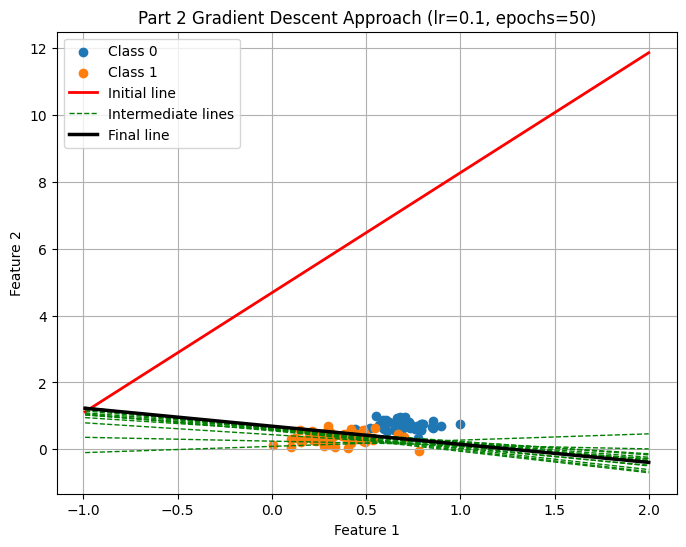

Saved figure: /content/Assignment_5/figures/part2_loss_lr_0.1_ep_50.png


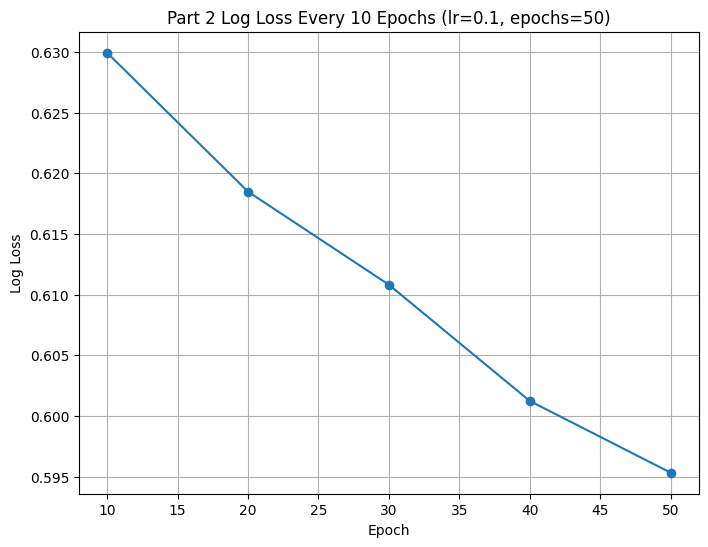

Saved figure: /content/Assignment_5/figures/part2_boundary_lr_0.1_ep_100.png


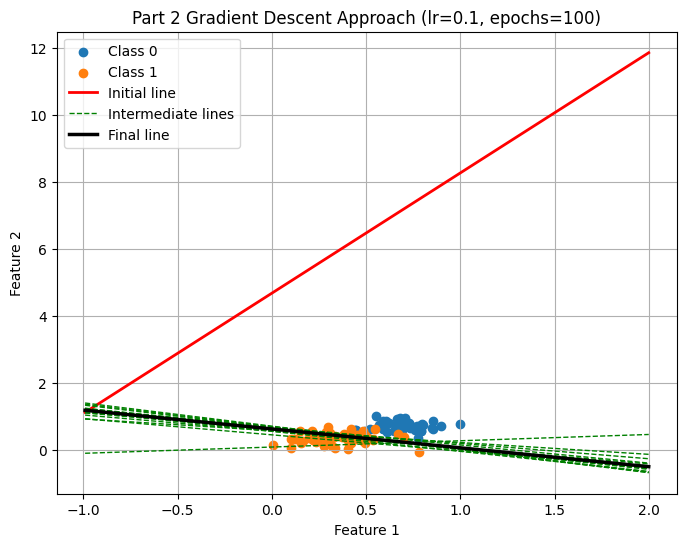

Saved figure: /content/Assignment_5/figures/part2_loss_lr_0.1_ep_100.png


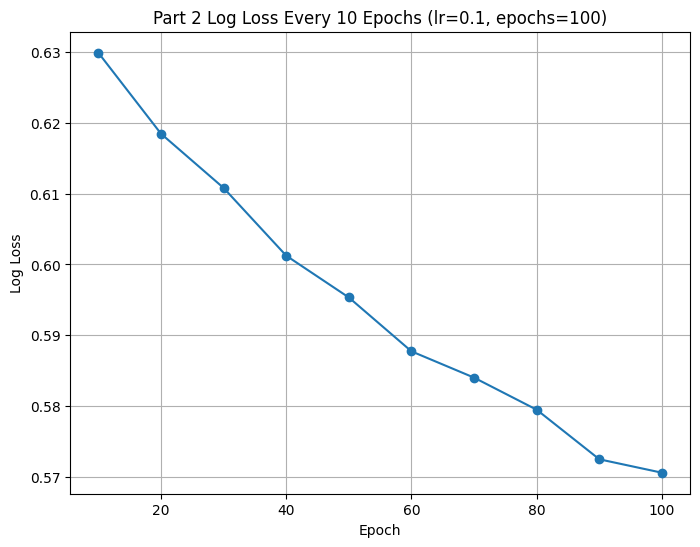

In [25]:
part2_fixed_lr = 0.1
part2_epoch_list = [20, 50, 100]

part2_results_ep = {}

for ep in part2_epoch_list:
    w, b, history, losses, accuracies, misclassified = train_part2_gradient_descent(
        X, y,
        learning_rate=part2_fixed_lr,
        epochs=ep,
        seed=42
    )

    part2_results_ep[ep] = {
        "w": w,
        "b": b,
        "history": history,
        "losses": losses,
        "accuracies": accuracies,
        "misclassified": misclassified
    }

    boundary_save_path = os.path.join(FIG_DIR, f"part2_boundary_lr_{part2_fixed_lr}_ep_{ep}.png")
    plot_decision_boundaries(
        X, y,
        history=history,
        title=f"Part 2 Gradient Descent Approach (lr={part2_fixed_lr}, epochs={ep})",
        save_path=boundary_save_path,
        max_intermediate_lines=15
    )

    epochs_axis_10 = list(range(10, ep + 1, 10))
    loss_every_10 = [losses[i - 1] for i in epochs_axis_10]

    plt.figure(figsize=(8, 6))
    plt.plot(epochs_axis_10, loss_every_10, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Log Loss")
    plt.title(f"Part 2 Log Loss Every 10 Epochs (lr={part2_fixed_lr}, epochs={ep})")
    plt.grid(True)

    loss_save_path = os.path.join(FIG_DIR, f"part2_loss_lr_{part2_fixed_lr}_ep_{ep}.png")
    plt.savefig(loss_save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {loss_save_path}")
    plt.show()

In [26]:
part2_summary_lr = []

for lr, result in part2_results_lr.items():
    final_loss = result["losses"][-1]
    final_acc = result["accuracies"][-1]
    final_mis = result["misclassified"][-1]

    part2_summary_lr.append({
        "experiment": f"lr={lr}, epochs={part2_fixed_epochs}",
        "final_log_loss": final_loss,
        "accuracy": final_acc,
        "last_epoch_misclassified": final_mis
    })

part2_summary_lr_df = pd.DataFrame(part2_summary_lr)
display(part2_summary_lr_df)

,experiment,final_log_loss,accuracy,last_epoch_misclassified
0,"lr=0.01, epochs=50",0.653952,0.92,8
1,"lr=0.1, epochs=50",0.595328,0.92,4
2,"lr=1.0, epochs=50",0.361025,0.79,4


In [27]:
part2_summary_ep = []

for ep, result in part2_results_ep.items():
    final_loss = result["losses"][-1]
    final_acc = result["accuracies"][-1]
    final_mis = result["misclassified"][-1]

    part2_summary_ep.append({
        "experiment": f"lr={part2_fixed_lr}, epochs={ep}",
        "final_log_loss": final_loss,
        "accuracy": final_acc,
        "last_epoch_misclassified": final_mis
    })

part2_summary_ep_df = pd.DataFrame(part2_summary_ep)
display(part2_summary_ep_df)

,experiment,final_log_loss,accuracy,last_epoch_misclassified
0,"lr=0.1, epochs=20",0.618487,0.77,4
1,"lr=0.1, epochs=50",0.595328,0.92,4
2,"lr=0.1, epochs=100",0.570548,0.81,6


In [28]:
comparison_df = pd.DataFrame([
    {
        "method": "Part 1 Heuristic",
        "learning_rate": part1_lr,
        "epochs": part1_epochs,
        "final_log_loss": loss1[-1],
        "accuracy": np.mean(predict_class(X, w1, b1) == y)
    },
    {
        "method": "Part 2 Gradient Descent",
        "learning_rate": part2_lr,
        "epochs": part2_epochs,
        "final_log_loss": loss2[-1],
        "accuracy": acc2[-1]
    }
])

display(comparison_df)

,method,learning_rate,epochs,final_log_loss,accuracy
0,Part 1 Heuristic,0.1,50,0.193322,0.93
1,Part 2 Gradient Descent,0.1,50,0.595328,0.92
